# A toy 21-cm Cosmology Emulator

We will approximate the sky-averaged 21-cm signal as a Gaussian absorption feature with three parameters: an amplitude $A$, a central redshift $z_c$, and a width $\sigma$. We will then build a simple emulator with a neural network to predict the signal temperature given a set of parameters and redshift input.

We will start by loading the relevant modules.

In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from tqdm import tqdm

## Generating training and test data

We need a set of example signals to train our neural network with and a set to test the accuracy of the emulator.

We are modelling the signal as a Gaussian so we need to define a function to generate gaussian signals. We will also need a function to generate a set of parameters for the signals and so need to define a prior over which to train our neural network emulator. When defining our prior we should bear in mind the prior we want to explore in our inference since outside the range of the prior the emulator will not be reliable.

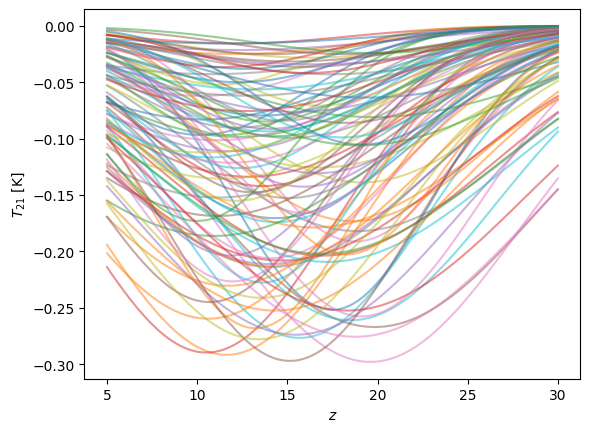

In [2]:
def gaussian(parameters):
    """a simple Gaussian function"""
    return -parameters[0] * \
        np.exp(-0.5*(z - parameters[1])**2/
               parameters[2]**2)

def prior(n):
    """a simple prior"""
    theta = np.ones((n, 3))
    theta[:, 0] = np.random.uniform(0.01, 0.3, n) # amplitude
    theta[:, 1] = np.random.uniform(10, 20, n) # mean
    theta[:, 2] = np.random.uniform(5, 10, n) # width
    return theta

z = np.linspace(5, 30, 100)[::-1]
n = 15000
parameters = prior(n)
signals = np.array([gaussian(parameters[i]) for i in range(n)])
[plt.plot(z, signals[i], alpha=0.5) for i in range(100)]
plt.xlabel(r'$z$')
plt.ylabel(r'$T_{21}$ [K]')
plt.savefig('gaussian-signals.png', dpi=300, bbox_inches='tight')


Once we have generated a large sample, here 15000, of signals we need to split the signals into a training and test set. Then we need to normalise the data so that the inputs and outputs of the network are all of order one. This makes the problem easier to fit.

Number of components to retain 99.99% variance: 5


/home/harry/Documents/Talks/Lectures/2024_mphil-data-intensive/mphil-lecture-examples/mphilenv/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/harry/Documents/Talks/Lectures/2024_mphil-data-intensive/mphil-lecture-examples/mphilenv/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


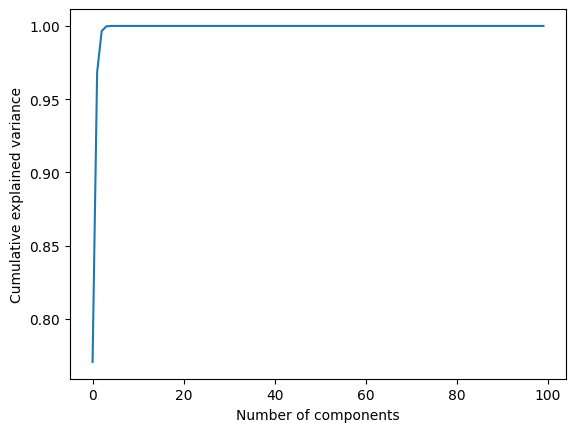

In [3]:
from sklearn.model_selection import train_test_split

train_params, test_params, train_signals, test_signals = train_test_split(
    parameters, signals, test_size=0.2, random_state=42
)

val_params, test_params, val_signals, test_signals = train_test_split(
    test_params, test_signals, test_size=0.5, random_state=42
)

cov = np.cov(train_signals.T)
eigenvalues, eigenvectors = np.linalg.eig(cov)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
cumulative_variance = np.cumsum(eigenvalues) / np.sum(eigenvalues)

plt.plot(cumulative_variance)
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.savefig('pca-variance.png', dpi=300, bbox_inches='tight')

n_components = np.where(cumulative_variance >= 0.9999)[0][0] + 1
print(f'Number of components to retain 99.99% variance: {n_components}')

# project the data onto the top n_components eigenvectors
train_pca = train_signals @ eigenvectors[:, :n_components]
val_pca = val_signals @ eigenvectors[:, :n_components]
test_pca = test_signals @ eigenvectors[:, :n_components]

norm_mean = np.mean(train_pca, axis=0)
norm_std = np.std(train_pca, axis=0)

train_pca = (train_pca - norm_mean) / norm_std
val_pca = (val_pca - norm_mean) / norm_std
test_pca = (test_pca - norm_mean) / norm_std


## Building the neural network and training

Now we can set up and train the neural network. We have to make some choice about the architecture of our network and the activation functions. Here we have 4 inputs (A, zc, sigma, z) and 5 PCA component weights to predict. We make the network a fully connected network and use sigmoid activation funciton on the input layer and hidden layers. We have a linear activation function on the output node.

We use the Adam optimizer (a fairly standard choice) to optimize the weights of the network connections. Adam is a stochastic gradient descent algorithm that uses moments to speed up the optimization and has an adaptive learning rate (step size to take at each iteration). We use a mean squared error loss function and run early stopping on the validation data to prevent over fitting.

In [23]:
class Emulator(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=16, num_layers=3):
        super(Emulator, self).__init__()
        input = nn.Linear(input_dim, hidden_dim)
        output = nn.Linear(hidden_dim, output_dim)

        self.layers = nn.ModuleList()
        self.layers.append(input)
        for i in range(num_layers):
            self.layers.append(nn.Linear(hidden_dim, hidden_dim))
        self.layers.append(output)

    def forward(self, x):
        x = torch.relu(self.layers[0](x))
        for layer in self.layers[1:-1]:
            x = torch.relu(layer(x))
        x = self.layers[-1](x)
        return x
    
input_dim = train_params.shape[1]
output_dim = train_pca.shape[1]

model = Emulator(input_dim, output_dim, hidden_dim=32)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_params_tensor = torch.tensor(train_params, dtype=torch.float32)
train_pca_tensor = torch.tensor(train_pca, dtype=torch.float32)
val_params_tensor = torch.tensor(val_params, dtype=torch.float32)
val_pca_tensor = torch.tensor(val_pca, dtype=torch.float32)

n_epochs = 1000
c, patience = 0, 20
best_val_loss = float('inf')
best_model_state = model.state_dict()

pbar = tqdm(range(n_epochs))

for epoch in pbar:
    model.train()
    optimizer.zero_grad()
    outputs = model(train_params_tensor)
    loss = criterion(outputs, train_pca_tensor)
    loss.backward()
    optimizer.step()
    
    model.eval()
    with torch.no_grad():
        val_outputs = model(val_params_tensor)
        val_loss = criterion(val_outputs, val_pca_tensor)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        c = 0
    else:
        c += 1
        if c >= patience:
            best_model_state = model.state_dict()
            best_val_loss = val_loss
            print(f'Early stopping at epoch {epoch+1}')
            break
    
    pbar.set_description(f'Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}')

model.load_state_dict(best_model_state)

Epoch 1000/1000, Loss: 0.0486, Val Loss: 0.0472: 100%|██████████| 1000/1000 [00:05<00:00, 182.43it/s]


<All keys matched successfully>

## Assessing the accuracy of our emulator

Here we demonstrate how to generate signals with the neural network emulator and assess the accuracy of the network when emulating the test data.

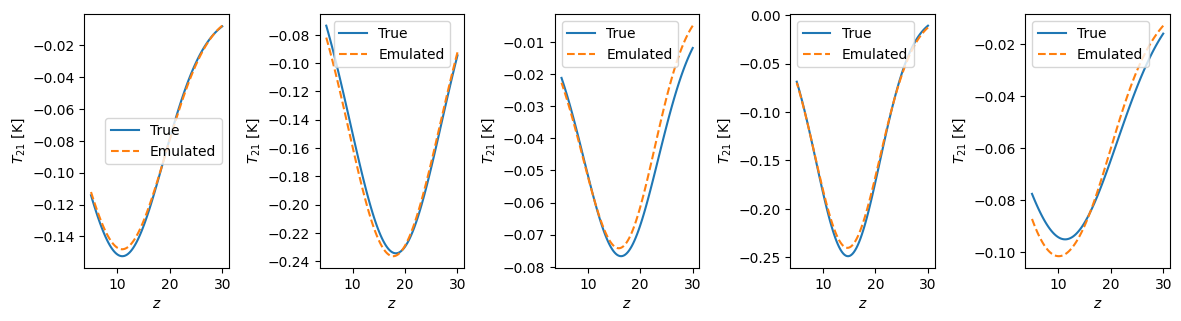

In [24]:
test_params_tensor = torch.tensor(test_params, dtype=torch.float32)
test_pca_tensor = torch.tensor(test_pca, dtype=torch.float32)

model.eval()
with torch.no_grad():
    test_outputs = model(test_params_tensor)

test_outputs = test_outputs.numpy() * norm_std + norm_mean
test_reconstructed = test_outputs @ eigenvectors[:, :n_components].T

plt.figure(figsize=(12, 6))
for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.plot(z, test_signals[i], label='True')
    plt.plot(z, test_reconstructed[i], label='Emulated', linestyle='dashed')
    plt.xlabel(r'$z$')
    plt.ylabel(r'$T_{21}$ [K]')
    plt.legend()
plt.tight_layout()
plt.savefig('emulator-results.png', dpi=300, bbox_inches='tight')

We can assess the overall accuracy of the network with the percentage error metric.

$\sigma = 100 \frac{\frac{1}{N}\sum_i |T_{\text{true}}(z_i) - T_{\text{emulated}}(z_i)|}{\mathrm{Max}(|T_{\text{true}}(z)|)}$

Mean error:  6.275932218481175  %
95th Percentile:  24.465644279428254  %


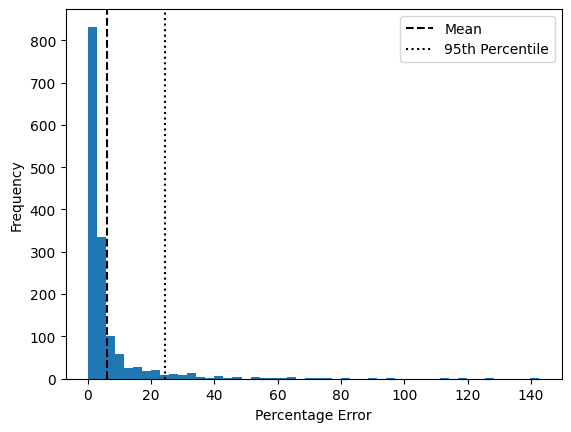

In [ ]:
error = [100 * np.mean(np.abs(test_reconstructed[i] - test_signals[i])) 
                        / np.max(np.abs(test_signals[i]))
            for i in range(len(test_params))]

print('Mean error: ', np.mean(error), ' %')
print('95th Percentile: ', np.quantile(error, 0.95), ' %')

plt.hist(error, bins=50)
plt.axvline(np.mean(error), label='Mean', ls='--', c='k')
plt.axvline(np.quantile(error, 0.95),
            label='95th Percentile', ls=':', c='k')
plt.legend()
plt.xlabel('Percentage Error')
plt.ylabel('Frequency')
plt.savefig('errors.png', dpi=300, bbox_inches='tight')
